In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import time

In [2]:
data_set = np.matrix(pd.read_csv("data.csv", header=None))
labels = np.array(pd.read_csv("data_labels.csv", header=None))
test_set = np.matrix(pd.read_csv("test_set.csv", header=None))
data_set.shape

(3486, 354)

In [3]:
n_in = data_set.shape[1]
n_h1 = data_set.shape[1]
n_h2 = data_set.shape[1]
n_out = 8
eta = 0.1

In [4]:
x_in = np.zeros((n_in, 1))
w_h1 = np.random.uniform(low=-0.1, high=0.1, size=(n_h1, n_in))*0.1
b_h1 = np.random.uniform(low=-0.1, high=0.1, size=(n_h1, 1))*0.1
w_h2 = np.random.uniform(low=-0.1, high=0.1, size=(n_h2, n_h1))*0.1
b_h2 = np.random.uniform(low=-0.1, high=0.1, size=(n_h2, 1))*0.1
w_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, n_h2))*0.1
b_out = np.random.uniform(low=-0.1, high=0.1, size=(n_out, 1))*0.1
d_out = np.zeros((n_out, 1))

In [5]:
Y = np.matrix([[1, 0, 0, 0, 0, 0, 0, 0],
               [0, 1, 0, 0, 0, 0, 0, 0],
               [0, 0, 1, 0, 0, 0, 0, 0],
               [0, 0, 0, 1, 0, 0, 0, 0],
               [0, 0, 0, 0, 1, 0, 0, 0],
               [0, 0, 0, 0, 0, 1, 0, 0],
               [0, 0, 0, 0, 0, 0, 1, 0],
               [0, 0, 0, 0, 0, 0, 0, 1]])

In [6]:
def getAccuracy(correct, overall_data):
    accuracy = (correct / overall_data) * 100
    print("Correct predictions: ", correct)
    print("Accuracy: ", accuracy)

def plot(figure):
    plt.figure()
    plt.plot(figure)
    plt.show()

def sigmoid(vector):
    return 1 / (1 + np.exp(-vector))

def sigmoidPrime(sigmoid):
    return np.multiply(sigmoid,(1-sigmoid))

In [7]:
max_epoch = 1000
total_err = np.zeros((max_epoch, 1))

# Ensure all data are numpy arrays
data_set = np.array(data_set)
Y = np.array(Y)
labels = np.array(labels)

for epoch in range(max_epoch):
    epoch_error = 0  # accumulate squared error
    
    for idx, row in enumerate(data_set[:3001]):
        # --- Prepare input and target as column vectors ---
        x_in = row.reshape(-1, 1)          # shape: (n_in,1)
        d_out = Y[labels[idx]-1].reshape(-1,1)  # shape: (n_out,1)
        
        # --- Forward propagation ---
        # Hidden layer 1
        v_h1 = np.dot(w_h1, x_in) + b_h1     # (n_h1,1)
        y_h1 = sigmoid(v_h1)                 # (n_h1,1)
        
        # Hidden layer 2
        v_h2 = np.dot(w_h2, y_h1) + b_h2     # (n_h2,1)
        y_h2 = sigmoid(v_h2)                 # (n_h2,1)
        
        # Output layer
        v_out = np.dot(w_out, y_h2) + b_out  # (n_out,1)
        out = sigmoid(v_out)                 # (n_out,1)
        
        # --- Compute error ---
        err = out - d_out
        #epoch_error += np.sum(err**2)
        
        # --- Backpropagation ---
        # Output layer delta
        delta_out = err * sigmoidPrime(out)                 # (n_out,1)
        
        # Hidden layer 2 delta
        delta_h2 = np.dot(w_out.T, delta_out) * sigmoidPrime(y_h2)  # (n_h2,1)
        
        # Hidden layer 1 delta
        delta_h1 = np.dot(w_h2.T, delta_h2) * sigmoidPrime(y_h1)   # (n_h1,1)
        
        # --- Update weights and biases ---
        w_out = w_out - eta * np.dot(delta_out, y_h2.T)   # (n_out, n_h2)
        b_out = b_out - eta * delta_out                   # (n_out,1)
        
        w_h2 = w_h2 - eta * np.dot(delta_h2, y_h1.T)     # (n_h2, n_h1)
        b_h2 = b_h2 - eta * delta_h2                     # (n_h2,1)
        
        w_h1 = w_h1 - eta * np.dot(delta_h1, x_in.T)     # (n_h1, n_in)
        b_h1 = b_h1 - eta * delta_h1                     # (n_h1,1)
    
    # --- Record total error for this epoch ---
    total_err[epoch] = total_err[epoch] + np.sum(err**2)
    print(f'Epoch {epoch+1}, Error: {total_err[epoch][0]}')
    
    # --- Termination condition ---
    if total_err[epoch] < 0.001:
        print("Training converged.")
        break

Epoch 1, Error: 0.8682858896090528
Epoch 2, Error: 0.963166788845937
Epoch 3, Error: 0.9884157421719184
Epoch 4, Error: 0.997379345050464
Epoch 5, Error: 0.9939952131748085
Epoch 6, Error: 0.9679894991269321
Epoch 7, Error: 0.8980592924910508
Epoch 8, Error: 0.7954147603736477
Epoch 9, Error: 0.7101638727907924
Epoch 10, Error: 0.6503903227707964
Epoch 11, Error: 0.6073931844795428
Epoch 12, Error: 0.5748451874230555
Epoch 13, Error: 0.5485677407511439
Epoch 14, Error: 0.5258135451886834
Epoch 15, Error: 0.5048592146534886
Epoch 16, Error: 0.48482296550379556
Epoch 17, Error: 0.4654623444130887
Epoch 18, Error: 0.446825665753293
Epoch 19, Error: 0.42900703154270875
Epoch 20, Error: 0.4120848739317844
Epoch 21, Error: 0.39609149975387126
Epoch 22, Error: 0.38099610866673206
Epoch 23, Error: 0.36671774831051235
Epoch 24, Error: 0.3531528836041006
Epoch 25, Error: 0.34020215496087053
Epoch 26, Error: 0.3277878098014894
Epoch 27, Error: 0.31586025023576747
Epoch 28, Error: 0.30439648083346

KeyboardInterrupt: 

In [8]:
# Validation phase
labels_test = labels[3001:]
correct = 0

for idx, row in enumerate(data_set[3001:]):
    x_in = row.reshape(-1, 1)  # column vector (n_in,1)

    # Hidden layer 1
    v_h1 = np.dot(w_h1, x_in) + b_h1
    y_h1 = sigmoid(v_h1)
    
    # Hidden layer 2
    v_h2 = np.dot(w_h2, y_h1) + b_h2
    y_h2 = sigmoid(v_h2)
    
    # Output layer
    v_out = np.dot(w_out, y_h2) + b_out
    out = sigmoid(v_out)
    # --- Prediction ---
    # Convert output column vector to 1D array and get index of max
    yy = np.argmax(out.flatten()) + 1  # +1 if labels are 1-indexed
    
    # Check if prediction matches label
    if yy == labels_test[idx]:
        correct += 1

# --- Accuracy ---
accuracy = correct / len(labels_test)
print(f'Validation Accuracy: {accuracy*100:.2f}%')

Validation Accuracy: 89.69%


In [9]:
# --- Test Phase ---
test_results = []

for row in test_set:
    x_in = row.reshape(-1, 1)  # (n_in,1)
    
    # --- Forward propagation ---
    # Hidden layer 1
    v_h1 = np.dot(w_h1, x_in) + b_h1
    y_h1 = sigmoid(v_h1)
    
    # Hidden layer 2
    v_h2 = np.dot(w_h2, y_h1) + b_h2
    y_h2 = sigmoid(v_h2)
    
    # Output layer
    v_out = np.dot(w_out, y_h2) + b_out
    out = sigmoid(v_out)
    
    # --- Prediction ---
    yy = np.argmax(out.flatten()) + 1  # +1 if labels are 1-indexed
    test_results.append(str(yy))

Correct predictions:  435
Accuracy:  89.69072164948454


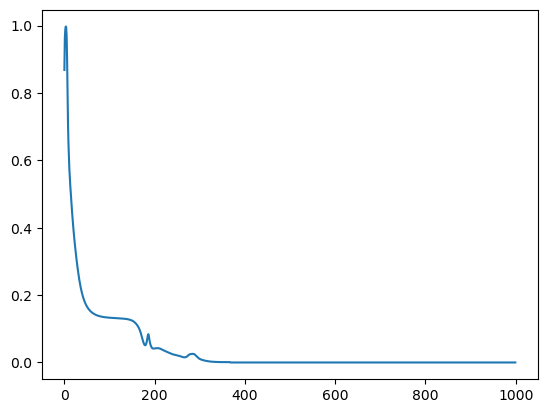

In [10]:
getAccuracy(correct, len(data_set[3001:]))
plot(total_err)

<h2>Your assignment<h2>

Tweak the neural network and do the following:

a. Make the number of neurons of the first hidden layer twice the size of the input layer <br>
b. Remove the 2nd hidden layer (it means that only 1 hidden layer is between the input and the output layer <br>
c. Run the neural network <br>
d. Observe the accuracy - did the results improve or worsen?<br>
e. Submit a jupyter notebook in LMS (Deadline will be on March 31)